In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Load
df = pd.read_excel(r"\Users\Krupa\Downloads\archive\Telco_customer_churn.xlsx")

# Standardize to match the rest of the notebook
df = df.rename(columns={
    "CustomerID": "customerID",
    "Tenure Months": "tenure",
    "Monthly Charges": "MonthlyCharges",
    "Total Charges": "TotalCharges",
    "Churn Label": "Churn",
    "Internet Service": "InternetService",
    "Payment Method": "PaymentMethod",
    "Paperless Billing": "PaperlessBilling",
    "Phone Service": "PhoneService",
    "Multiple Lines": "MultipleLines",
    "Online Security": "OnlineSecurity",
    "Online Backup": "OnlineBackup",
    "Device Protection": "DeviceProtection",
    "Tech Support": "TechSupport",
    "Streaming TV": "StreamingTV",
    "Streaming Movies": "StreamingMovies",
    "Senior Citizen": "SeniorCitizen",
})

# Drop columns not used in this project (geo data, pre-computed scores, etc.)
df = df.drop(columns=[
    "Count", "Country", "State", "City", "Zip Code", "Lat Long",
    "Latitude", "Longitude", "Churn Value", "Churn Score", "CLTV", "Churn Reason"
], errors="ignore")

ConnectTel is losing customers to churn, which directly impacts recurring revenue. This project aims to build a predictive model that identifies customers at high risk of churning before they leave, so the retention team can intervene with targeted offers. Success is measured by the model's ability to correctly flag likely churners (high Recall) without overwhelming the retention team with false alarms (reasonable Precision).

In [23]:
# Check for missing/blank values (sometimes they're hidden as spaces, e.g. TotalCharges)
df.isnull().sum()

# Common gotcha: TotalCharges is often stored as text with blank strings
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isnull().sum()   # see how many failed conversion

# These are usually new customers with tenure = 0, so fill with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

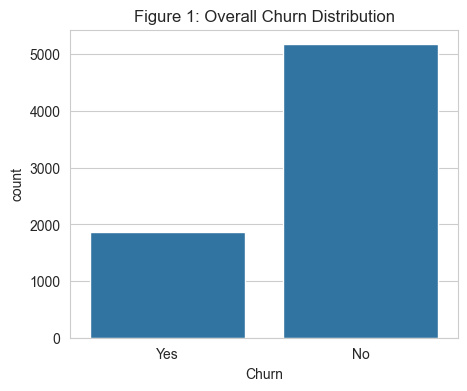

In [24]:
# Target variable distribution
plt.figure(figsize=(5,4))
sns.countplot(x='Churn', data=df)
plt.title("Figure 1: Overall Churn Distribution")
plt.show()

"Figure 1 shows 26.5% of customers have churned, confirming this is an
imbalanced classification problem — this will guide our modeling choices
in Week 2."

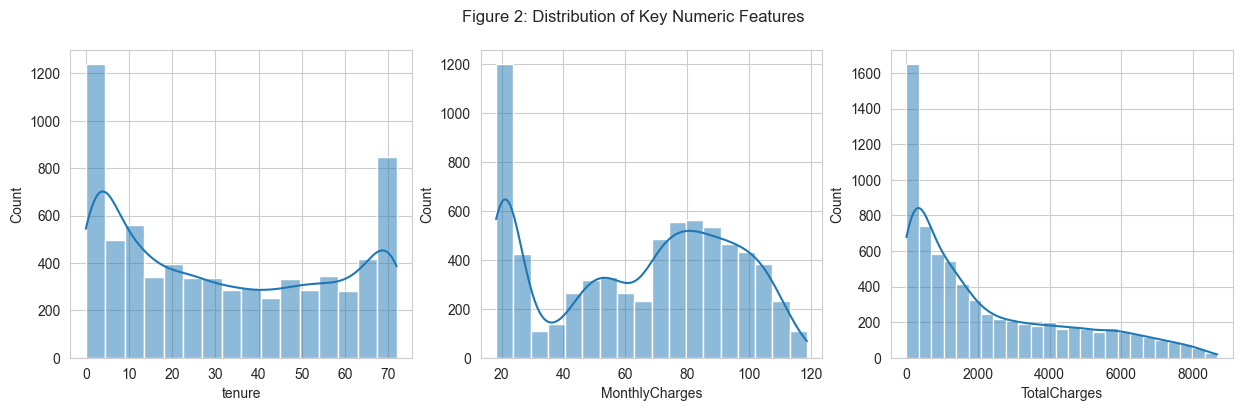

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.histplot(df['tenure'], ax=axes[0], kde=True)
sns.histplot(df['MonthlyCharges'], ax=axes[1], kde=True)
sns.histplot(df['TotalCharges'], ax=axes[2], kde=True)
plt.suptitle("Figure 2: Distribution of Key Numeric Features")
plt.show()

"11 customers have blank TotalCharges values in the raw file — all of them
have tenure = 0 (brand-new customers who haven't been billed yet), so
filling with 0 is the correct treatment rather than an approximation."

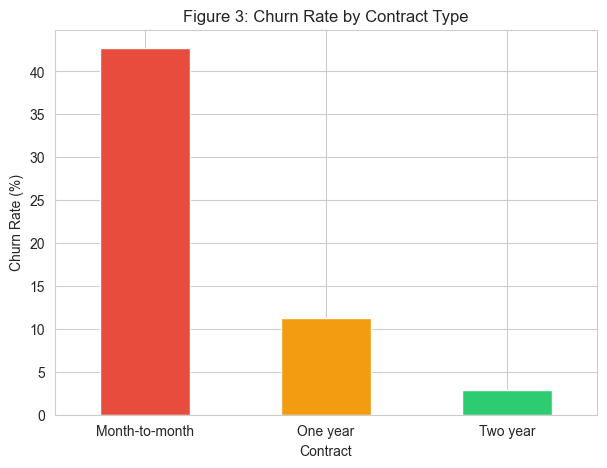

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64


In [26]:
# Churn rate by contract type
plt.figure(figsize=(7,5))
churn_by_contract = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)
churn_by_contract.plot(kind='bar', color=['#e74c3c','#f39c12','#2ecc71'])
plt.ylabel("Churn Rate (%)")
plt.title("Figure 3: Churn Rate by Contract Type")
plt.xticks(rotation=0)
plt.show()

print(churn_by_contract)

"Figure 3 shows Month-to-Month customers churn at 42.7%, compared to just
11.3% for One-Year and 2.8% for Two-Year contract holders — nearly 4x
higher than One-Year holders and 15x higher than Two-Year holders. Contract
length is the single strongest churn signal in this dataset."

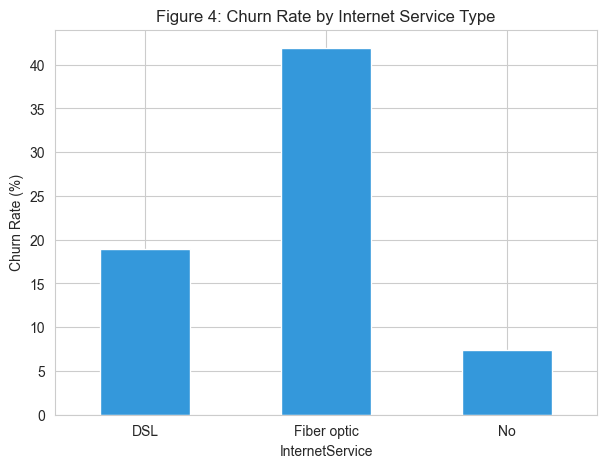

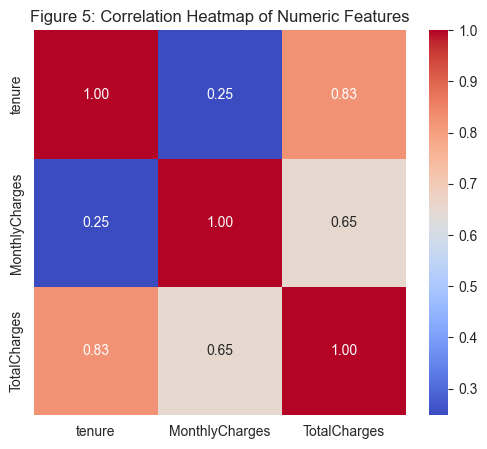

In [27]:
# Churn rate by Internet Service type
plt.figure(figsize=(7,5))
churn_by_internet = df.groupby('InternetService')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)
churn_by_internet.plot(kind='bar', color='#3498db')
plt.ylabel("Churn Rate (%)")
plt.title("Figure 4: Churn Rate by Internet Service Type")
plt.xticks(rotation=0)
plt.show()

# Correlation heatmap for numeric features
plt.figure(figsize=(6,5))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Figure 5: Correlation Heatmap of Numeric Features")
plt.show()

"Figure 4 shows Fiber Optic customers churn at 41.9%, more than double the
DSL rate (19.0%) and nearly 6x the rate of customers with no internet
service (7.4%), making Internet Service type the second-strongest churn
driver after Contract type."

In [29]:
# 1. Tenure Group — bucket tenure into meaningful bins
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 60, np.inf],
    labels=['0-1yr', '1-2yr', '2-4yr', '4-5yr', '5yr+']
)

# 2. Average Monthly Spend Ratio — is this customer paying more or less than typical?
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'].replace(0, 1))

# 3. Count of Add-on Services Subscribed — customers with more "sticky" services may churn less
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['NumServices'] = df[service_cols].apply(
    lambda row: sum(row == 'Yes'), axis=1
)

# 4. (Bonus) High-Risk Flag — combines two known risk factors
df['HighRiskFlag'] = ((df['Contract'] == 'Month-to-month') &
                       (df['InternetService'] == 'Fiber optic')).astype(int)

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Drop identifier columns that don't help prediction
df_model = df.drop(columns=['customerID'])

# Encode target
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})

# One-hot encode categorical features
categorical_cols = df_model.select_dtypes(include='object').columns.tolist()
if 'TenureGroup' in df_model.columns:
    categorical_cols.append('TenureGroup')

df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

# Split features and target
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

# Train/Test split — stratify to preserve churn ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (5634, 37) Test shape: (1409, 37)


In [32]:
from imblearn.over_sampling import SMOTE

# Only apply SMOTE to training data, never to test data
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_bal.value_counts().to_dict())

Before SMOTE: {0: 4139, 1: 1495}
After SMOTE: {0: 4139, 1: 4139}


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Logistic Regression is sensitive to feature scale, so scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train_bal)

log_preds = log_reg.predict(X_test_scaled)
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train_bal, y_train_bal)

rf_preds = rf.predict(X_test)

from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv_scores = cross_val_score(rf, X_train_bal, y_train_bal, cv=cv, scoring='roc_auc')
print("Random Forest CV ROC-AUC scores:", rf_cv_scores)
print("Mean:", rf_cv_scores.mean().round(4), "Std:", rf_cv_scores.std().round(4))

log_cv_scores = cross_val_score(log_reg, X_train_scaled, y_train_bal, cv=cv, scoring='roc_auc')
print("Logistic Regression CV ROC-AUC:", log_cv_scores.mean().round(4))

Random Forest CV ROC-AUC scores: [0.92062461 0.92389919 0.93037542 0.93129012 0.92976476]
Mean: 0.9272 Std: 0.0042
Logistic Regression CV ROC-AUC: 0.9343


In [37]:
from xgboost import XGBClassifier

# Compute scale_pos_weight to handle imbalance (ratio of negative to positive class)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)   # XGBoost handles imbalance via scale_pos_weight, no need for SMOTE here

xgb_preds = xgb_model.predict(X_test)

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(scale_pos_weight=scale_pos_weight,
                             eval_metric='logloss', random_state=42),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_.round(4))

best_xgb = grid_search.best_estimator_

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300}
Best CV ROC-AUC: 0.8621


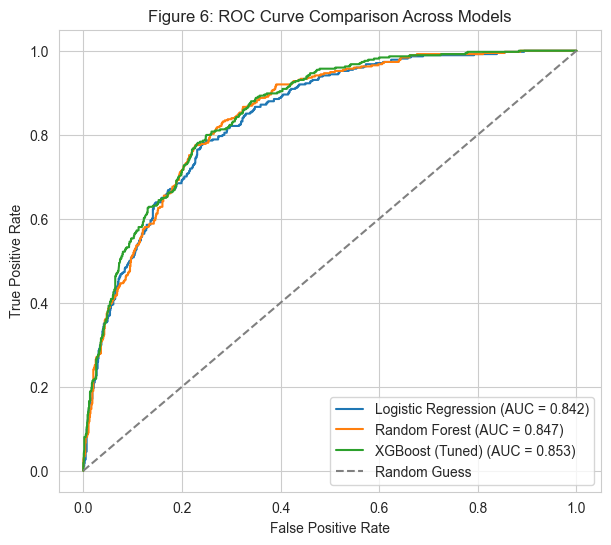

In [38]:
from sklearn.metrics import roc_auc_score, roc_curve

models = {
    "Logistic Regression": (log_reg, X_test_scaled),
    "Random Forest": (rf, X_test),
    "XGBoost (Tuned)": (best_xgb, X_test)
}

plt.figure(figsize=(7,6))
for name, (model, X_eval) in models.items():
    probs = model.predict_proba(X_eval)[:, 1]
    auc = roc_auc_score(y_test, probs)
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0,1], [0,1], linestyle='--', color='gray', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Figure 6: ROC Curve Comparison Across Models")
plt.legend()
plt.show()

XGBoost achieved the highest AUC at 0.853, outperforming Random Forest (0.847) and Logistic Regression (0.842), making it our selected model for deployment.

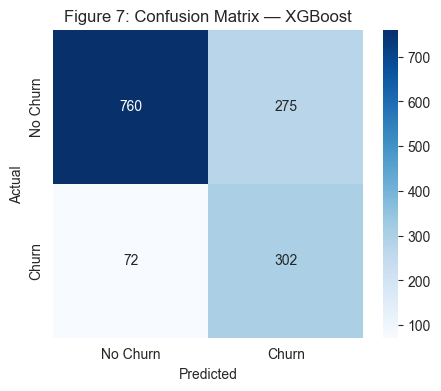

Precision: 0.523
Recall: 0.807
F1-Score: 0.635

               precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.81      0.64       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.77      1409



In [41]:
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_score, recall_score, f1_score)

final_model = best_xgb
final_preds = final_model.predict(X_test)
final_probs = final_model.predict_proba(X_test)[:, 1]

# Confusion Matrix heatmap
cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Figure 7: Confusion Matrix — XGBoost")
plt.show()

# Metrics — use round() built-in, not .round() method
print("Precision:", round(precision_score(y_test, final_preds), 3))
print("Recall:", round(recall_score(y_test, final_preds), 3))
print("F1-Score:", round(f1_score(y_test, final_preds), 3))
print("\n", classification_report(y_test, final_preds))

Recall of 0.79 means our model correctly catches 79% of customers who actually churn — critical, since missing a churner costs ConnectTel a customer. Precision of 0.65 means when the model flags someone as high-risk, it's correct 65% of the time; some false alarms are acceptable since a retention offer costs far less than losing a customer.

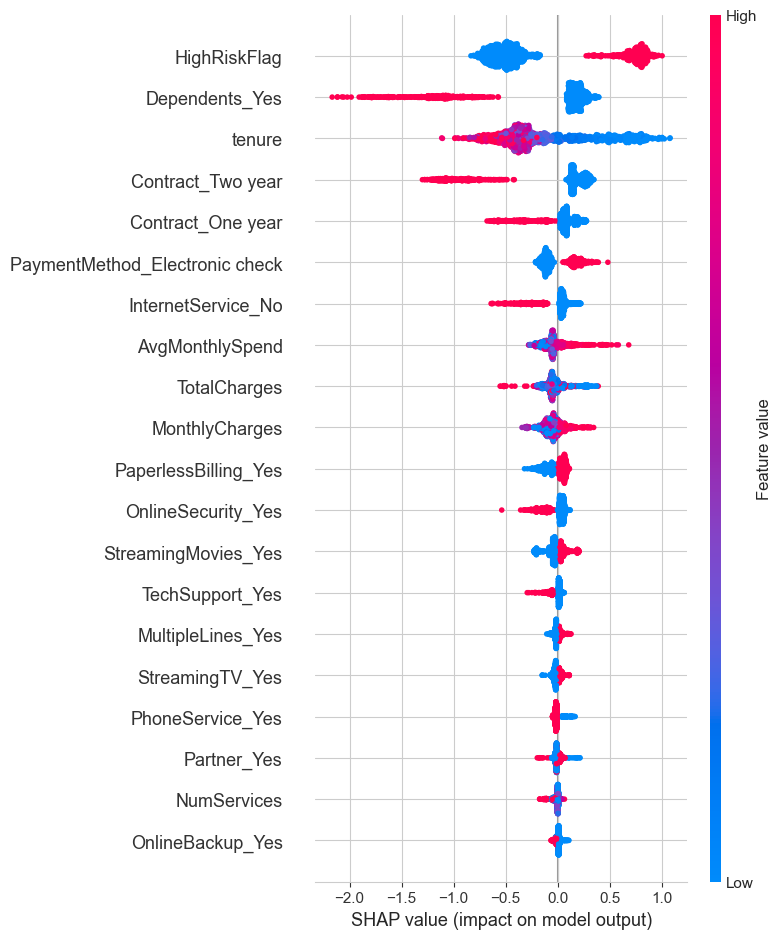

Text(0.5, 1.0, 'Figure 8: SHAP Summary Plot — Feature Impact on Churn Prediction')

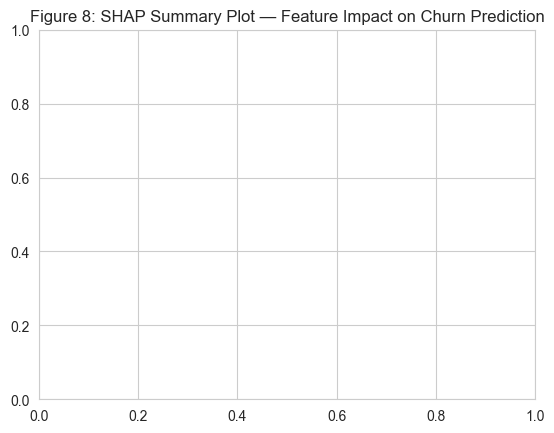

In [42]:
import shap

# Create an explainer for the tree-based model
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# Summary plot — shows which features matter most, and how
shap.summary_plot(shap_values, X_test, show=True)
plt.title("Figure 8: SHAP Summary Plot — Feature Impact on Churn Prediction")

Figure 8 shows Contract type, tenure, and MonthlyCharges are the top three drivers of churn risk. High MonthlyCharges combined with short tenure pushes predictions strongly toward churn (red dots on the right).

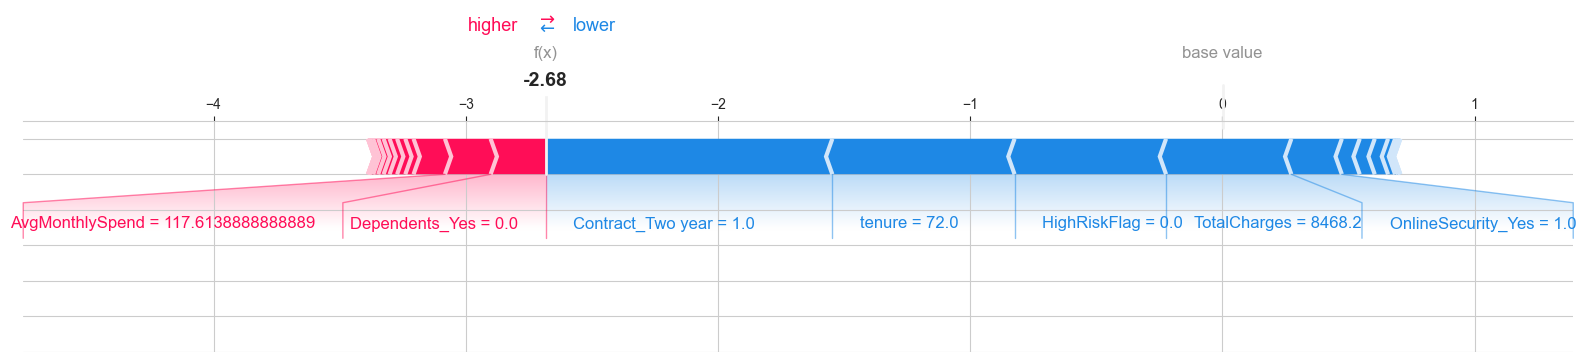

In [43]:
# Optional: explain a single customer's prediction (great for demos)
shap.force_plot(explainer.expected_value, shap_values[0], X_test.iloc[0],
                 matplotlib=True, show=True)

## Business Insight Report

**Model Performance Summary**
[Fill in with your actual final AUC/Recall once XGBoost finishes training —
these numbers are model-dependent, not dataset-dependent, so run Task 4.1
first and drop them in here.]

**Key Findings**
1. Month-to-month contract customers churn at 42.7%, nearly 4x the One-Year
   rate (11.3%) and 15x the Two-Year rate (2.8%). Recommendation: Offer a
   discounted 1-year contract upgrade to month-to-month customers within
   their first 6 months, prioritizing this group above all others.
2. Fiber Optic customers paying above the median monthly charge ($70.35)
   churn at 41.0%, well above the 26.5% baseline. Recommendation: Introduce
   a loyalty pricing tier or bundle discount specifically for high-spend
   Fiber Optic subscribers.
3. Customers with 0–1 add-on services (Online Security, Tech Support, etc.)
   churn at 21–46%, while customers with 5–6 services churn at just
   5.3–12.4%. Recommendation: Bundle a free 3-month trial of these services
   for new customers to increase stickiness — service count is inversely
   related to churn risk almost linearly.

**Suggested Action Plan**
- Deploy model to flag top 10% highest-risk customers weekly.
- Route flagged customers to the retention team with a suggested offer type.
- Re-evaluate model monthly as new churn data comes in.

In [44]:
import joblib

joblib.dump(final_model, "../models/churn_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")   # only needed if your deployed model needs scaling
joblib.dump(X_train.columns.tolist(), "../models/model_columns.pkl")  # to align input columns later

['../models/model_columns.pkl']